# Libraries

In [1]:
import numpy as np
import pandas as pd
import re
from datetime import date, datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_validate, GridSearchCV, RandomizedSearchCV, ParameterGrid
from sklearn.base import clone

from itertools import product
from sklearn.feature_selection import SelectFromModel
import os
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Load Data

In [2]:
test = pd.read_csv('Data/Updated 2025-2026.csv')
train = pd.read_csv('Data/Updated_Training.csv')

In [3]:
MONTHS = {
    "jan": 1, "feb": 2, "mar": 3, "apr": 4, "may": 5, "jun": 6,
    "jul": 7, "aug": 8, "sep": 9, "oct": 10, "nov": 11, "dec": 12
}

def fix_score_cell(x):
    # keep missing
    if pd.isna(x):
        return x

    # if it's already a real date/datetime
    if isinstance(x, (pd.Timestamp, datetime, date)):
        return f"{x.month}-{x.day}"

    # if it's a string, try to undo Excel-like date strings (e.g., "8-Sep")
    if isinstance(x, str):
        s = x.strip()

        # already looks like W-L (e.g., "15-12")
        if re.fullmatch(r"\d{1,2}-\d{1,2}", s):
            return s

        # "8-Sep"  -> "9-8"
        m = re.fullmatch(r"(\d{1,2})-([A-Za-z]{3,})", s)
        if m:
            day = int(m.group(1))
            mon = m.group(2)[:3].lower()
            if mon in MONTHS:
                return f"{MONTHS[mon]}-{day}"

        # "Sep-8" -> "9-8"
        m = re.fullmatch(r"([A-Za-z]{3,})-(\d{1,2})", s)
        if m:
            mon = m.group(1)[:3].lower()
            day = int(m.group(2))
            if mon in MONTHS:
                return f"{MONTHS[mon]}-{day}"

    return x

for col in train.columns.union(test.columns):
    if col in train.columns:
        train[col] = train[col].map(fix_score_cell)
    if col in test.columns:
        test[col] = test[col].map(fix_score_cell)


In [4]:
train.head()

,RecordID,Season,Team,Conference,Overall Seed,Bid Type,NET Rank,PrevNET,AvgOppNETRank,AvgOppNET,...,3P%,FT%,OR,DR,REB,AST,STL,BLK,TO,PF
0,2020-21-UCDavis,2020-21,UC Davis,Big West,NaN,NaN,223.0,224.0,240.0,211.0,...,33.2,77.9,9.2,22.2,31.5,10.9,7.4,2.8,14.6,19.6
1,2020-21-MichiganSt.,2020-21,Michigan St.,Big Ten,43.0,AL,70.0,70.0,20.0,75.0,...,32.1,72.7,10.9,26.6,37.4,15.9,4.5,4.7,13.0,19.8
2,2020-21-ULM,2020-21,ULM,Sun Belt,NaN,NaN,292.0,292.0,244.0,214.0,...,34.0,70.3,7.9,22.5,30.4,13.7,7.4,2.8,13.0,16.7
3,2020-21-CentralConn.St.,2020-21,Central Conn. St.,NEC,NaN,NaN,301.0,301.0,200.0,195.0,...,32.4,70.2,8.7,23.0,31.6,12.9,6.9,2.6,14.2,17.1
4,2020-21-Colgate,2020-21,Colgate,Patriot,57.0,AQ,9.0,9.0,154.0,169.0,...,40.3,72.3,9.8,30.1,39.9,17.6,7.1,3.4,10.8,16.2


In [5]:
test.head()

,RecordID,Season,Team,Conference,Bid Type,NET Rank,PrevNET,AvgOppNETRank,AvgOppNET,WL,...,3P%,FT%,OR,DR,REB,AST,STL,BLK,TO,PF
0,2025-26-Coastal Carolina,2025-26,Coastal Carolina,Sun Belt,NaN,229,218,260,221,18-13,...,33.9,72.9,10.6,29.5,40.1,10.4,4.4,3.3,10.8,18.4
1,2025-26-Washington St.,2025-26,Washington St.,WCC,NaN,141,143,91,135,11-20,...,36.9,74.2,9.8,24.5,34.3,13.9,5.6,2.9,13.0,17.8
2,2025-26-Nicholls,2025-26,Nicholls,Southland,NaN,248,249,194,196,12-18,...,33.4,66.7,10.5,20.6,31.1,13.2,9.0,2.7,11.9,17.8
3,2025-26-FGCU,2025-26,FGCU,ASUN,NaN,246,247,270,225,14-18,...,32.4,71.9,11.9,25.0,36.9,14.7,7.7,3.6,11.0,18.6
4,2025-26-Eastern Mich.,2025-26,Eastern Mich.,MAC,NaN,240,240,177,189,9-21,...,32.2,72.8,10.0,25.5,35.5,12.6,5.9,4.2,11.9,18.3


# EDA

## Independend vars

In [6]:
# train.drop(columns=['Bid Type'], inplace=True)

# Basic EDA for `train`
print("Shape:", train.shape)

print("\nInfo:")
train.info()

print("\nNumeric summary:")
display(train.describe().T)

Shape: (1353, 36)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 1353 entries, 0 to 1352
Data columns (total 36 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   RecordID              1353 non-null   str    
 1   Season                1353 non-null   str    
 2   Team                  1353 non-null   str    
 3   Conference            1353 non-null   str    
 4   Overall Seed          249 non-null    float64
 5   Bid Type              249 non-null    str    
 6   NET Rank              1348 non-null   float64
 7   PrevNET               1348 non-null   float64
 8   AvgOppNETRank         1348 non-null   float64
 9   AvgOppNET             1348 non-null   float64
 10  WL                    1353 non-null   str    
 11  Conf.Record           1353 non-null   str    
 12  Non-ConferenceRecord  1353 non-null   str    
 13  RoadWL                1353 non-null   str    
 14  NETSOS                1348 non-null   float64
 15  NETNonC

,count,mean,std,min,25%,50%,75%,max
Overall Seed,249.0,33.377510,19.394931,1.00,17.000,32.000,49.000,68.000
NET Rank,1348.0,177.919139,103.483643,1.00,90.000,177.000,268.250,363.000
PrevNET,1348.0,177.928042,103.477228,1.00,89.750,177.000,268.250,363.000
AvgOppNETRank,1348.0,175.824184,103.177438,1.00,86.750,174.000,264.000,364.000
AvgOppNET,1348.0,176.043769,53.528173,49.00,130.750,187.000,217.000,300.000
NETSOS,1348.0,176.367953,102.836488,1.00,88.000,174.000,264.000,364.000
NETNonConfSOS,1338.0,177.131540,103.984770,1.00,87.000,175.000,267.000,364.000
ORtg,1353.0,104.813821,7.361365,79.40,99.800,104.400,109.600,130.100
DRtg,1353.0,104.529933,6.611092,86.30,100.000,105.000,109.600,122.100
AdjT,1353.0,67.536955,2.494024,59.10,65.900,67.500,69.100,75.300


In [7]:
# Fill non-tournament seeds with NaN for better analysis
train['Overall Seed'] = train['Overall Seed'].fillna(0).astype(int)
train['Compete'] = train['Overall Seed'] > 0
train['Compete'] = train['Compete'].astype(int)

# Missing values
miss = train.isnull().sum().sort_values(ascending=False)
miss_pct = (train.isnull().mean()*100).round(2).sort_values(ascending=False)
display(pd.concat([miss, miss_pct], axis=1, keys=['missing','pct_missing']))

,missing,pct_missing
Bid Type,1104,81.60
NETNonConfSOS,15,1.11
PrevNET,5,0.37
NET Rank,5,0.37
AvgOppNET,5,0.37
PF,5,0.37
TO,5,0.37
STL,5,0.37
OR,5,0.37
FG%,5,0.37


## Feature Engineer

In [8]:
def win_pct(record):
    try:
        w, l = map(int, record.split('-'))
        return float(w / (w + l))
    except:
        return 10e-6  # small number to avoid division by zero

scores_cols = ['WL', 'Conf.Record', 'Non-ConferenceRecord', 'RoadWL', 'Quadrant1', 'Quadrant2', 'Quadrant3', 'Quadrant4']
for col in scores_cols:
    train[f'{col}_Win'] = train[col].apply(lambda x: int(x.split('-')[0]) if isinstance(x, str) else None)
    test[f'{col}_Win']  = test[col].apply(lambda x: int(x.split('-')[0]) if isinstance(x, str) else None)
    train[f'{col}_Loss'] = train[col].apply(lambda x: int(x.split('-')[1]) if isinstance(x, str) else None)
    test[f'{col}_Loss']  = test[col].apply(lambda x: int(x.split('-')[1]) if isinstance(x, str) else None)

In [9]:
# ---------- helpers ----------
def safe_pct(w, l):
    denom = w + l
    return np.where(denom > 0, w / denom, 0.0)

def add_record_features(df):
    # WL_Win, WL_Loss, Conf.Record_Win, Conf.Record_Loss, etc.
    rec_pairs = [
        ("WL", "WL_Win", "WL_Loss"),
        ("Conf", "Conf.Record_Win", "Conf.Record_Loss"),
        ("NonConf", "Non-ConferenceRecord_Win", "Non-ConferenceRecord_Loss"),
        ("Road", "RoadWL_Win", "RoadWL_Loss"),
        ("Q1", "Quadrant1_Win", "Quadrant1_Loss"),
        ("Q2", "Quadrant2_Win", "Quadrant2_Loss"),
        ("Q3", "Quadrant3_Win", "Quadrant3_Loss"),
        ("Q4", "Quadrant4_Win", "Quadrant4_Loss"),
    ]
    
    for prefix, wcol, lcol in rec_pairs:
        if wcol in df.columns and lcol in df.columns:
            df[f"{prefix}_Pct"] = safe_pct(df[wcol], df[lcol])
            df[f"{prefix}_Net"] = df[wcol] - df[lcol]
            df[f"{prefix}_Games"] = df[wcol] + df[lcol]

    return df


def add_committee_style_features(df):
    # Efficiency / strength
    df["EffMargin"] = df["ORtg"] - df["DRtg"]
    df["NetMomentum"] = df["PrevNET"] - df["NET Rank"]
    df["SOS_Diff"] = df["NETSOS"] - df["NETNonConfSOS"]

    # Resume-style features
    df["Bad_Losses"] = df["Quadrant3_Loss"] + df["Quadrant4_Loss"]
    df["Good_Wins"] = 2 * df["Quadrant1_Win"] + df["Quadrant2_Win"]
    df["Elite_Wins"] = df["Quadrant1_Win"]
    df["ResumeScore"] = (
        3.0 * df["Quadrant1_Win"]
        + 1.5 * df["Quadrant2_Win"]
        - 2.0 * df["Quadrant3_Loss"]
        - 3.0 * df["Quadrant4_Loss"]
    )

    # Exposure / difficulty
    df["High_Level_Games"] = (
        df["Quadrant1_Win"] + df["Quadrant1_Loss"]
        + df["Quadrant2_Win"] + df["Quadrant2_Loss"]
    )
    df["Q1Q2_WinPct"] = safe_pct(
        df["Quadrant1_Win"] + df["Quadrant2_Win"],
        df["Quadrant1_Loss"] + df["Quadrant2_Loss"]
    )

    # Ratios
    df["Q1_Share"] = np.where(df["WL_Win"] > 0, df["Quadrant1_Win"] / df["WL_Win"], 0.0)
    df["Q12_Share"] = np.where(
        df["WL_Win"] > 0,
        (df["Quadrant1_Win"] + df["Quadrant2_Win"]) / df["WL_Win"],
        0.0
    )

    # Logs
    for col in ["NET Rank", "PrevNET", "AvgOppNET", "AvgOppNETRank", "NETSOS", "NETNonConfSOS"]:
        if col in df.columns:
            safe_name = col.replace(" ", "_").replace(".", "")
            df[f"log_{safe_name}"] = np.log1p(df[col].clip(lower=0))

    return df


def add_interactions(df):
    # committee-like interaction terms
    df["NET_x_Eff"] = df["NET Rank"] * df["EffMargin"]
    df["NET_x_WinPct"] = df["NET Rank"] * df["WL_Pct"]
    df["Resume_x_SOS"] = df["ResumeScore"] * df["NETSOS"]
    df["Q1_x_NET"] = df["Quadrant1_Win"] * df["NET Rank"]
    df["Eff_x_SOS"] = df["EffMargin"] * df["NETSOS"]
    df["GoodWins_x_Eff"] = df["Good_Wins"] * df["EffMargin"]
    df["BadLosses_x_NET"] = df["Bad_Losses"] * df["NET Rank"]
    df["Road_x_Q1"] = df["Road_Pct"] * df["Quadrant1_Win"]
    return df


def add_season_relative_ranks(df):
    # lower is better for NET / SOS-like rank columns
    asc_rank_cols = ["NET Rank", "PrevNET", "AvgOppNET", "AvgOppNETRank", "NETSOS", "NETNonConfSOS"]
    desc_rank_cols = [
        "EffMargin", "ResumeScore", "WL_Pct", "Conf_Pct", "NonConf_Pct", "Road_Pct",
        "Q1_Pct", "Q2_Pct", "Q1Q2_WinPct", "Good_Wins", "ORtg", "PTS", "FG%", "3P%", "FT%"
    ]

    for col in asc_rank_cols:
        if col in df.columns:
            cname = col.replace(" ", "_").replace(".", "")
            df[f"SRank_{cname}"] = df.groupby("Season")[col].rank(method="average", ascending=True)

    for col in desc_rank_cols:
        if col in df.columns:
            cname = col.replace(" ", "_").replace(".", "")
            df[f"SRank_{cname}"] = df.groupby("Season")[col].rank(method="average", ascending=False)

    composite_parts = [
        c for c in [
            "SRank_NET_Rank",
            "SRank_EffMargin",
            "SRank_ResumeScore",
            "SRank_WL_Pct",
            "SRank_NETSOS"
        ] if c in df.columns
    ]
    if composite_parts:
        df["CompositeRank"] = df[composite_parts].mean(axis=1)

    return df


def add_pseudo_elo_features(df):
    # not true Elo; these are Elo-like proxies from season-summary data
    # useful when you do NOT have game-by-game logs
    zcols = []

    def add_z(col, ascending=True, name=None):
        if col not in df.columns:
            return
        nm = name or col.replace(" ", "_").replace(".", "")
        season_mean = df.groupby("Season")[col].transform("mean")
        season_std = df.groupby("Season")[col].transform("std").replace(0, np.nan)
        z = (df[col] - season_mean) / season_std
        if ascending:
            z = -z  # lower rank is better
        df[f"Z_{nm}"] = z.fillna(0.0)
        zcols.append(f"Z_{nm}")

    add_z("NET Rank", ascending=True, name="NET")
    add_z("PrevNET", ascending=True, name="PrevNET")
    add_z("NETSOS", ascending=True, name="SOS")
    add_z("AvgOppNET", ascending=True, name="OppNET")
    add_z("EffMargin", ascending=False, name="EffMargin")
    add_z("ResumeScore", ascending=False, name="Resume")
    add_z("WL_Pct", ascending=False, name="WinPct")
    add_z("Q1Q2_WinPct", ascending=False, name="Top2WinPct")
    add_z("Road_Pct", ascending=False, name="RoadPct")

    if zcols:
        df["PseudoElo"] = (
            1500
            + 40 * df["Z_NET"]
            + 30 * df["Z_EffMargin"]
            + 25 * df["Z_Resume"]
            + 20 * df["Z_WinPct"]
            + 15 * df["Z_Top2WinPct"]
            + 10 * df["Z_RoadPct"]
            + 10 * df["Z_SOS"]
        )
        df["PseudoElo_Rank"] = df.groupby("Season")["PseudoElo"].rank(method="average", ascending=False)
        df["PseudoElo_Delta"] = df["Z_NET"] - df["Z_PrevNET"]

    return df


def engineer_all(df):
    df = df.copy()
    df = add_record_features(df)
    df = add_committee_style_features(df)
    df = add_interactions(df)
    df = add_season_relative_ranks(df)
    df = add_pseudo_elo_features(df)
    return df

In [10]:
train = engineer_all(train)
test = engineer_all(test)

In [11]:
train.head()

,RecordID,Season,Team,Conference,Overall Seed,Bid Type,NET Rank,PrevNET,AvgOppNETRank,AvgOppNET,...,Z_SOS,Z_OppNET,Z_EffMargin,Z_Resume,Z_WinPct,Z_Top2WinPct,Z_RoadPct,PseudoElo,PseudoElo_Rank,PseudoElo_Delta
0,2020-21-UCDavis,2020-21,UC Davis,Big West,0,NaN,223.0,224.0,240.0,211.0,...,-0.971909,-0.775507,-0.350496,-0.202543,0.257777,-0.845479,0.882357,1456.465881,154.0,0.009675
1,2020-21-MichiganSt.,2020-21,Michigan St.,Big Ten,43,AL,70.0,70.0,20.0,75.0,...,1.632000,1.677042,0.982215,1.703058,0.387934,0.980696,-0.515909,1646.360744,44.0,-0.000232
2,2020-21-ULM,2020-21,ULM,Sun Belt,0,NaN,292.0,292.0,244.0,214.0,...,-1.472268,-0.829607,-0.962613,-2.108145,-1.037536,-0.845479,-1.012395,1313.446337,252.0,-0.000136
3,2020-21-CentralConn.St.,2020-21,Central Conn. St.,NEC,0,NaN,301.0,301.0,200.0,195.0,...,-0.747258,-0.486972,-1.528240,-1.323485,-1.192544,-0.845479,-0.941468,1317.410771,250.0,-0.000132
4,2020-21-Colgate,2020-21,Colgate,Patriot,57,AQ,9.0,9.0,154.0,169.0,...,-0.900429,-0.018102,0.703275,0.582116,2.268703,3.415596,2.888565,1716.838150,18.0,-0.000258


In [12]:
test.head()

,RecordID,Season,Team,Conference,Bid Type,NET Rank,PrevNET,AvgOppNETRank,AvgOppNET,WL,...,Z_SOS,Z_OppNET,Z_EffMargin,Z_Resume,Z_WinPct,Z_Top2WinPct,Z_RoadPct,PseudoElo,PseudoElo_Rank,PseudoElo_Delta
0,2025-26-Coastal Carolina,2025-26,Coastal Carolina,Sun Belt,NaN,229,218,260,221,18-13,...,-1.317402,-0.695143,-0.512357,-0.413801,0.445901,1.301337,1.092104,1483.030361,194.0,-0.104255
1,2025-26-Washington St.,2025-26,Washington St.,WCC,NaN,141,143,91,135,11-20,...,0.834039,0.854831,0.171220,0.051189,-0.777831,-0.821967,-1.429992,1488.493238,185.0,0.018955
2,2025-26-Nicholls,2025-26,Nicholls,Southland,NaN,248,249,194,196,12-18,...,0.151643,-0.244569,-0.460346,-0.350393,-0.533084,-0.350122,-0.005917,1438.331497,232.0,0.009478
3,2025-26-FGCU,2025-26,FGCU,ASUN,NaN,246,247,270,225,14-18,...,-0.852994,-0.767235,-0.490066,-0.963335,-0.329857,-0.821967,-0.775856,1402.115630,262.0,0.009478
4,2025-26-Eastern Mich.,2025-26,Eastern Mich.,MAC,NaN,240,240,177,189,9-21,...,0.350675,-0.118408,-0.475206,-0.625160,-1.075023,-0.291141,-0.964751,1416.497296,253.0,0.000000


In [13]:
# one‑hot encode the categorical fields we identified earlier
test_dummy  = pd.get_dummies(test,  columns=['Conference', 'Team'], drop_first=True, dtype=int)
train_dummy = pd.get_dummies(train, columns=['Conference', 'Team'], drop_first=True, dtype=int)

In [14]:
train_dummy.head()

,RecordID,Season,Overall Seed,Bid Type,NET Rank,PrevNET,AvgOppNETRank,AvgOppNET,WL,Conf.Record,...,Team_Wichita St.,Team_William & Mary,Team_Winthrop,Team_Wisconsin,Team_Wofford,Team_Wright St.,Team_Wyoming,Team_Xavier,Team_Yale,Team_Youngstown St.
0,2020-21-UCDavis,2020-21,0,NaN,223.0,224.0,240.0,211.0,9-8,7-5,...,0,0,0,0,0,0,0,0,0,0
1,2020-21-MichiganSt.,2020-21,43,AL,70.0,70.0,20.0,75.0,15-12,9-12,...,0,0,0,0,0,0,0,0,0,0
2,2020-21-ULM,2020-21,0,NaN,292.0,292.0,244.0,214.0,7-19,5-14,...,0,0,0,0,0,0,0,0,0,0
3,2020-21-CentralConn.St.,2020-21,0,NaN,301.0,301.0,200.0,195.0,5-16,5-13,...,0,0,0,0,0,0,0,0,0,0
4,2020-21-Colgate,2020-21,57,AQ,9.0,9.0,154.0,169.0,14-1,14-1,...,0,0,0,0,0,0,0,0,0,0


In [15]:
test_dummy.head()

,RecordID,Season,Bid Type,NET Rank,PrevNET,AvgOppNETRank,AvgOppNET,WL,Conf.Record,Non-ConferenceRecord,...,Team_Wichita St.,Team_William & Mary,Team_Winthrop,Team_Wisconsin,Team_Wofford,Team_Wright St.,Team_Wyoming,Team_Xavier,Team_Yale,Team_Youngstown St.
0,2025-26-Coastal Carolina,2025-26,NaN,229,218,260,221,18-13,11-8,7-5,...,0,0,0,0,0,0,0,0,0,0
1,2025-26-Washington St.,2025-26,NaN,141,143,91,135,11-20,7-12,4-8,...,0,0,0,0,0,0,0,0,0,0
2,2025-26-Nicholls,2025-26,NaN,248,249,194,196,12-18,12-10,0-8,...,0,0,0,0,0,0,0,0,0,0
3,2025-26-FGCU,2025-26,NaN,246,247,270,225,14-18,10-11,4-7,...,0,0,0,0,0,0,0,0,0,0
4,2025-26-Eastern Mich.,2025-26,NaN,240,240,177,189,9-21,4-14,5-7,...,0,0,0,0,0,0,0,0,0,0


## Target Var

<Axes: xlabel='Compete'>

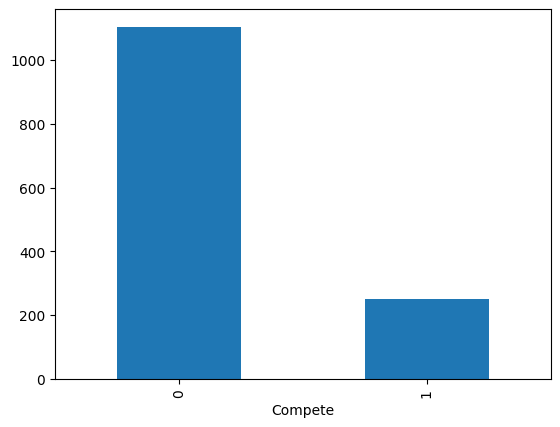

In [16]:
train['Compete'].value_counts().plot(kind='bar')

In [17]:
train_compete = train_dummy[train_dummy['Compete'] == 1].copy()
train_compete.info()

<class 'pandas.DataFrame'>
Index: 249 entries, 1 to 1351
Columns: 530 entries, RecordID to Team_Youngstown St.
dtypes: float64(85), int64(434), str(11)
memory usage: 1.0 MB


## Relations

Correlation with Compete:


Compete           1.000000
Good_Wins         0.671284
GoodWins_x_Eff    0.667806
Elite_Wins        0.644975
Quadrant1_Win     0.644975
                    ...   
PseudoElo_Rank   -0.574539
CompositeRank    -0.577417
SRank_WL_Pct     -0.581378
log_PrevNET      -0.703125
log_NET_Rank     -0.703495
Name: Compete, Length: 90, dtype: float64

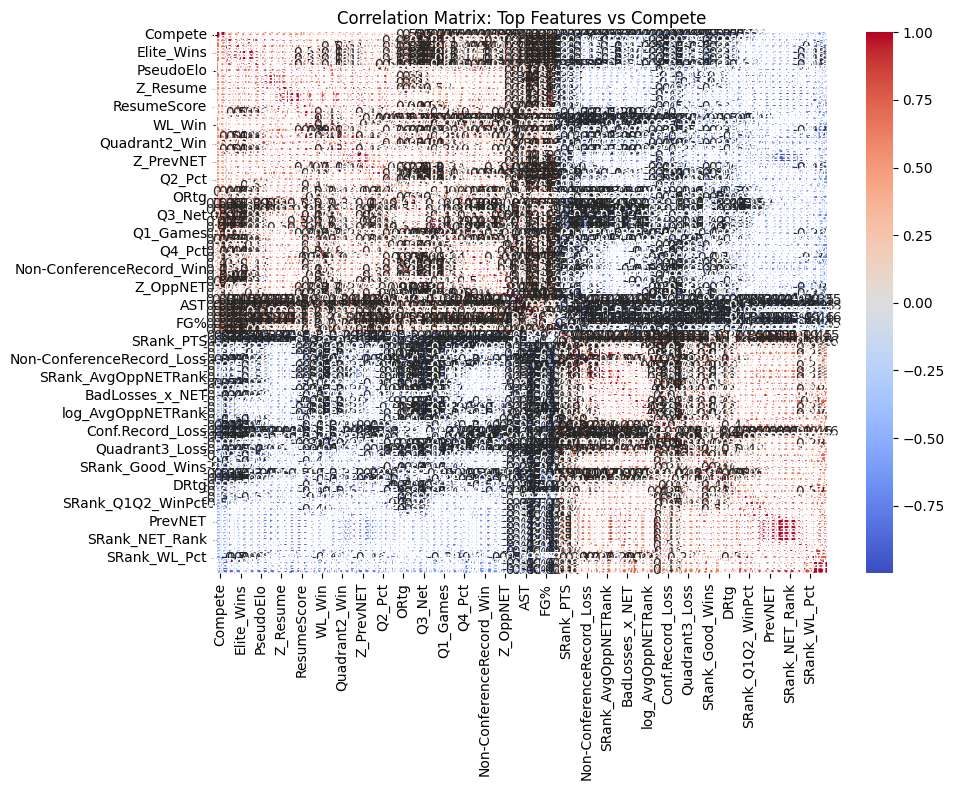

In [18]:
# Analyze the relationship between other variables and 'Overall Seed'
# eparate numeric and categorical columns
numeric_cols = train_dummy.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('Overall Seed')
numeric_cols.remove('Compete')

# Correlation analysis for numeric features
print("Correlation with Compete:")
correlation = train_dummy[numeric_cols + ['Compete']].corr()['Compete'].sort_values(ascending=False)

# Correlation > abs(0.3) and remove NaN correlations
top_corr_compete = correlation.dropna()[correlation.dropna().abs() > 0.3]

display(top_corr_compete)

# Visualize correlations
plt.figure(figsize=(10, 8))
sns.heatmap(train_dummy[top_corr_compete.index.tolist()].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix: Top Features vs Compete')
plt.tight_layout()
plt.show()

# Classify Compete and Non-Compete

## Pipeline

In [27]:
selected_classifier_features = top_corr_compete.index.tolist()
X_cls = train_dummy[selected_classifier_features].drop(columns=['Compete']).copy()
groups = train_dummy['Season'].copy()  # Assuming 'Season' is the grouping variable
y_cls = train_dummy["Compete"].copy()

In [28]:
from sklearn.model_selection import GroupKFold, cross_validate

gkf = GroupKFold(n_splits=5)

scoring = {
    'roc_auc': 'roc_auc',
    'accuracy': 'accuracy',
    'f1': 'f1'
}

def evaluate_classifier(name, pipeline, X, y, groups, cv=gkf, scoring=scoring):
    print(f"\n=== {name} ===")

    scores = cross_validate(
        pipeline,
        X, y,
        cv=cv,
        groups=groups,
        scoring=scoring,
        n_jobs=1,
        return_train_score=True
    )

    print(f"Train ROC AUC: {scores['train_roc_auc'].mean():.4f} ± {scores['train_roc_auc'].std():.4f}")
    print(f"Test  ROC AUC: {scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}")
    print(f"Train Accuracy: {scores['train_accuracy'].mean():.4f} ± {scores['train_accuracy'].std():.4f}")
    print(f"Test  Accuracy: {scores['test_accuracy'].mean():.4f} ± {scores['test_accuracy'].std():.4f}")
    print(f"Train F1: {scores['train_f1'].mean():.4f} ± {scores['train_f1'].std():.4f}")
    print(f"Test  F1: {scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}")

    return scores

## Classifiers

In [29]:
scale_pos_weight=X_cls[y_cls==0].shape[0] / X_cls[y_cls==1].shape[0]

classifiers = {
    # "RF": {
    #     "classifier": RandomForestClassifier(
    #         random_state=42,
    #         n_jobs=-1,
    #         class_weight="balanced"
    #     ),
    #     "param_grid": {
    #         "clf__n_estimators": [200, 300, 500],
    #         "clf__max_depth": [None, 5, 10, 20],
    #         "clf__min_samples_split": [2, 5, 10],
    #         "clf__min_samples_leaf": [1, 2, 4],
    #         "clf__max_features": ["sqrt", None]
    #     }
    # },

    "XGB": {
        "classifier": XGBClassifier(
            random_state=42,
            n_jobs=-1,
            objective="binary:logistic",
            eval_metric="logloss",
            scale_pos_weight=scale_pos_weight,
            verbosity=0
        ),
        "param_grid": {
            "clf__n_estimators": [100, 200, 300],
            "clf__learning_rate": [0.01, 0.05, 0.1],
            "clf__max_depth": [3, 5, 7],
            "clf__subsample": [0.8, 1.0],
            "clf__colsample_bytree": [0.8, 1.0],
            "clf__reg_alpha": [0, 0.1, 1],
            "clf__reg_lambda": [1, 2, 5]
        }
    }
    # "LightGBM": {
    #     "classifier": LGBMClassifier(
    #         random_state=42,
    #         n_jobs=-1,
    #         verbose=-1,
    #         class_weight="balanced"
    #     ),
    #     "param_grid": {
    #         "clf__n_estimators": [200, 300, 500],
    #         "clf__learning_rate": [0.03, 0.05, 0.1],
    #         "clf__max_depth": [3, 4, 5],
    #         "clf__num_leaves": [7, 15, 31],
    #         "clf__min_child_samples": [10, 20],
    #         "clf__subsample": [0.8, 1.0],
    #         "clf__colsample_bytree": [0.8, 1.0]
    #     }
    # }
}

## Tune

In [30]:
all_classifier_results = []

for algo_name, algo_cfg in classifiers.items():
    base_clf = algo_cfg["classifier"]
    param_grid = algo_cfg["param_grid"]

    grid_iter = ParameterGrid(param_grid) if param_grid else [{}]

    for params in grid_iter:
        clf = clone(base_clf)

        pipe = Pipeline([
            ("clf", clf)
        ])

        pipe.set_params(**params)

        param_str = ", ".join(
            f"{k.split('__')[1]}={v}" for k, v in params.items()
        ) if params else "default"

        model_name = f"{algo_name}({param_str})"

        scores = evaluate_classifier(model_name, pipe, X_cls, y_cls, groups)

        all_classifier_results.append({
            "model": algo_name,
            "params": param_str,
            "train_roc_auc_mean": scores["train_roc_auc"].mean(),
            "train_roc_auc_std": scores["train_roc_auc"].std(),
            "test_roc_auc_mean": scores["test_roc_auc"].mean(),
            "test_roc_auc_std": scores["test_roc_auc"].std(),
            "train_accuracy_mean": scores["train_accuracy"].mean(),
            "test_accuracy_mean": scores["test_accuracy"].mean(),
            "train_f1_mean": scores["train_f1"].mean(),
            "test_f1_mean": scores["test_f1"].mean(),
            "auc_gap": scores["train_roc_auc"].mean() - scores["test_roc_auc"].mean()
        })

classifier_results_df = pd.DataFrame(all_classifier_results).sort_values(
    "test_roc_auc_mean", ascending=False
)

os.makedirs("Results", exist_ok=True)

display(classifier_results_df)

out_path = "Results/Classifiers_Results.txt"
classifier_results_df.to_csv(out_path, index=False, sep="\t")
print(f"Wrote results to {out_path}")


=== XGB(colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, reg_alpha=0, reg_lambda=1, subsample=0.8) ===
Train ROC AUC: 0.9900 ± 0.0011
Test  ROC AUC: 0.9763 ± 0.0081
Train Accuracy: 0.9403 ± 0.0049
Test  Accuracy: 0.9253 ± 0.0160
Train F1: 0.8540 ± 0.0101
Test  F1: 0.8157 ± 0.0380

=== XGB(colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, reg_alpha=0, reg_lambda=1, subsample=1.0) ===
Train ROC AUC: 0.9886 ± 0.0010
Test  ROC AUC: 0.9738 ± 0.0079
Train Accuracy: 0.9386 ± 0.0053
Test  Accuracy: 0.9202 ± 0.0126
Train F1: 0.8504 ± 0.0107
Test  F1: 0.8026 ± 0.0284

=== XGB(colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, reg_alpha=0, reg_lambda=2, subsample=0.8) ===
Train ROC AUC: 0.9896 ± 0.0011
Test  ROC AUC: 0.9761 ± 0.0082
Train Accuracy: 0.9398 ± 0.0048
Test  Accuracy: 0.9261 ± 0.0161
Train F1: 0.8529 ± 0.0097
Test  F1: 0.8179 ± 0.0382

=== XGB(colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, 

,model,params,train_roc_auc_mean,train_roc_auc_std,test_roc_auc_mean,test_roc_auc_std,train_accuracy_mean,test_accuracy_mean,train_f1_mean,test_f1_mean,auc_gap
233,XGB,"colsample_bytree=0.8, learning_rate=0.05, max_...",0.999607,1.985718e-04,0.980088,0.007734,0.987623,0.937875,0.967516,0.836162,0.019520
448,XGB,"colsample_bytree=0.8, learning_rate=0.1, max_d...",0.999986,1.225443e-05,0.979908,0.007266,0.996675,0.940103,0.991043,0.838457,0.020078
713,XGB,"colsample_bytree=1.0, learning_rate=0.05, max_...",0.999814,1.341895e-04,0.979879,0.007459,0.991135,0.940130,0.976483,0.839925,0.019934
219,XGB,"colsample_bytree=0.8, learning_rate=0.05, max_...",0.999974,2.223004e-05,0.979865,0.006854,0.993720,0.940144,0.983277,0.838857,0.020109
443,XGB,"colsample_bytree=0.8, learning_rate=0.1, max_d...",1.000000,4.965068e-17,0.979851,0.006399,0.999631,0.942295,0.998995,0.840189,0.020149
...,...,...,...,...,...,...,...,...,...,...,...
603,XGB,"colsample_bytree=1.0, learning_rate=0.01, max_...",0.998903,4.137105e-04,0.969596,0.013018,0.983744,0.933452,0.957574,0.824830,0.029308
597,XGB,"colsample_bytree=1.0, learning_rate=0.01, max_...",0.998977,4.276222e-04,0.969220,0.012781,0.984113,0.930492,0.958559,0.816248,0.029757
541,XGB,"colsample_bytree=1.0, learning_rate=0.01, max_...",0.997942,5.167324e-04,0.969093,0.012089,0.974319,0.927540,0.934093,0.812296,0.028849
601,XGB,"colsample_bytree=1.0, learning_rate=0.01, max_...",0.999297,4.232031e-04,0.967678,0.011855,0.985222,0.926783,0.961338,0.806948,0.031619


Wrote results to Results/Classifiers_Results.txt


## Model Selection

In [32]:
out_path = "Results/Classifiers_Results.txt"
with open(out_path, "r", encoding="utf-8") as f:
    text = f.read()

pattern = re.compile(
    r"===\s*(.*?)\s*===\s*"
    r"Train ROC AUC:\s*([0-9.]+)\s*±\s*([0-9.]+)\s*"
    r"Test\s+ROC AUC:\s*([0-9.]+)\s*±\s*([0-9.]+)\s*"
    r"Train Accuracy:\s*([0-9.]+)\s*±\s*([0-9.]+)\s*"
    r"Test\s+Accuracy:\s*([0-9.]+)\s*±\s*([0-9.]+)\s*"
    r"Train F1:\s*([0-9.]+)\s*±\s*([0-9.]+)\s*"
    r"Test\s+F1:\s*([0-9.]+)\s*±\s*([0-9.]+)",
    re.DOTALL
)

matches = pattern.findall(text)

rows = []
for (
    model_name,
    train_roc_auc_mean, train_roc_auc_std,
    test_roc_auc_mean, test_roc_auc_std,
    train_acc_mean, train_acc_std,
    test_acc_mean, test_acc_std,
    train_f1_mean, train_f1_std,
    test_f1_mean, test_f1_std
) in matches:

    train_roc_auc_mean = float(train_roc_auc_mean)
    train_roc_auc_std = float(train_roc_auc_std)
    test_roc_auc_mean = float(test_roc_auc_mean)
    test_roc_auc_std = float(test_roc_auc_std)

    train_acc_mean = float(train_acc_mean)
    train_acc_std = float(train_acc_std)
    test_acc_mean = float(test_acc_mean)
    test_acc_std = float(test_acc_std)

    train_f1_mean = float(train_f1_mean)
    train_f1_std = float(train_f1_std)
    test_f1_mean = float(test_f1_mean)
    test_f1_std = float(test_f1_std)

    rows.append({
        "model": model_name.strip(),

        "train_roc_auc_mean": train_roc_auc_mean,
        "train_roc_auc_std": train_roc_auc_std,
        "test_roc_auc_mean": test_roc_auc_mean,
        "test_roc_auc_std": test_roc_auc_std,
        "roc_auc_gap": abs(train_roc_auc_mean - test_roc_auc_mean),

        "train_accuracy_mean": train_acc_mean,
        "train_accuracy_std": train_acc_std,
        "test_accuracy_mean": test_acc_mean,
        "test_accuracy_std": test_acc_std,
        "accuracy_gap": abs(train_acc_mean - test_acc_mean),

        "train_f1_mean": train_f1_mean,
        "train_f1_std": train_f1_std,
        "test_f1_mean": test_f1_mean,
        "test_f1_std": test_f1_std,
        "f1_gap": abs(train_f1_mean - test_f1_mean)
    })

results_df = pd.DataFrame(rows)

# best by highest test ROC AUC
best_test_rocauc = results_df.loc[results_df["test_roc_auc_mean"].idxmax()]

# best by smallest ROC-AUC gap
best_gap = results_df.loc[results_df["roc_auc_gap"].idxmin()]

# Top 10 highest test ROC AUC
print("\n=== Top 10 by Highest Test ROC AUC ===")
print(
    results_df.sort_values("test_roc_auc_mean", ascending=False)
    .head(10)[[
        "model", "train_roc_auc_mean", "test_roc_auc_mean",
        "roc_auc_gap", "test_accuracy_mean", "test_f1_mean"
    ]]
    .to_string(index=False)
)

# Top 10 smallest ROC AUC gap
print("\n=== Top 10 by Smallest ROC AUC Gap ===")
print(
    results_df.sort_values("roc_auc_gap", ascending=True)
    .head(10)[[
        "model", "train_roc_auc_mean", "test_roc_auc_mean",
        "roc_auc_gap", "test_accuracy_mean", "test_f1_mean"
    ]]
    .to_string(index=False)
)

# Balanced score: HIGHER roc_auc is better, LOWER gap is better
results_df["balanced_score"] = (
    results_df["test_roc_auc_mean"] - 0.5 * results_df["roc_auc_gap"]
)

print("\n=== 5 Most Balanced Models ===")
print(
    results_df.sort_values("balanced_score", ascending=False)
    .head(5)[[
        "model", "train_roc_auc_mean", "test_roc_auc_mean",
        "roc_auc_gap", "test_accuracy_mean", "test_f1_mean", "balanced_score"
    ]]
    .to_string(index=False)
)


=== Top 10 by Highest Test ROC AUC ===
                                                                                                                   model  train_roc_auc_mean  test_roc_auc_mean  roc_auc_gap  test_accuracy_mean  test_f1_mean
  XGB(colsample_bytree=0.8, learning_rate=0.05, max_depth=5, n_estimators=100, reg_alpha=1, reg_lambda=5, subsample=1.0)              0.9996             0.9801       0.0195              0.9379        0.8362
   XGB(colsample_bytree=0.8, learning_rate=0.1, max_depth=7, n_estimators=100, reg_alpha=1, reg_lambda=5, subsample=0.8)              1.0000             0.9799       0.0201              0.9401        0.8385
  XGB(colsample_bytree=0.8, learning_rate=0.05, max_depth=5, n_estimators=100, reg_alpha=0, reg_lambda=2, subsample=1.0)              1.0000             0.9799       0.0201              0.9401        0.8389
 XGB(colsample_bytree=0.8, learning_rate=0.1, max_depth=7, n_estimators=100, reg_alpha=0.1, reg_lambda=5, subsample=1.0)            

In [33]:

# XGB(colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=300, reg_alpha=0.1, reg_lambda=2, subsample=1.0)
best_classifier = XGBClassifier(
    random_state=42,
    n_jobs=-1,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    verbosity=0,
    n_estimators=300,
    learning_rate=0.01,
    max_depth=3,
    subsample=1.0,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=2
)

## Predict Compete -  Non Compete

In [ ]:
best_classifier.fit(X_cls, y_cls)

# Predict probabilities
test_dummy["Compete_Prob"] = best_classifier.predict_proba(test_dummy.reindex(columns=X_cls.columns, fill_value=0))[:, 1]

# Force exactly top 68
test_dummy["Overall Seed"] = 0
top_68_idx = test_dummy["Compete_Prob"].nlargest(68).index
test_dummy.loc[top_68_idx, "Overall Seed"] = None

print(test_dummy["Overall Seed"].value_counts())

test_dummy[["RecordID", "Overall Seed"]].to_csv("Results/Classified.csv", index=False)

Compete
0.0    297
Name: count, dtype: int64
